# Company Bankruptcy Prediction
### Ayush Saxena
- Email-Id = reignofayush@gmail.com

In [1]:
import sys
sys.version

'3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]'

## Importing all Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import fbeta_score
from sklearn.inspection import permutation_importance

import shap
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

## Loading the Dataset

In [3]:
df = pd.read_csv("BFSI Dataset.csv")

In [4]:
df.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490,1


In [5]:
df.shape

(6819, 95)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 95 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1    ROA(A) before interest and % after tax                   6819 non-null   float64
 2    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3    Operating Gross Margin                                   6819 non-null   float64
 4    Realized Sales Gross Margin                              6819 non-null   float64
 5    Operating Profit Rate                                    6819 non-null   float64
 6    Pre-tax net Interest Rate                                6819 non-null   float64
 7    After-tax net Interest Rate                              6819 non-null   float64
 8    Non-industry inco

- It looks like there are **no Categorical** features in the Dataset, although some Categorical features might be disguised as **Numerical** features with **Binary** values.

#### Cleaning the Dataset

In [7]:
# Removing Leading or Trailing spaces
df.columns = df.columns.str.strip()

In [8]:
# Removing Special Characters
df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", col) for col in df.columns]

In [9]:
#  Removing only Trailing underscores
df.columns = df.columns.str.rstrip("_")

## Statistical Analysis

In [10]:
df.describe()

,ROA_C_before_interest_and_depreciation_before_interest,ROA_A_before_interest_and_after_tax,ROA_B_before_interest_and_depreciation_after_tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,Pre_tax_net_Interest_Rate,After_tax_net_Interest_Rate,Non_industry_income_and_expenditure_revenue,Continuous_interest_rate_after_tax,...,Net_Income_to_Total_Assets,Total_assets_to_GNP_price,No_credit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholder_s_Equity,Liability_to_Equity,Degree_of_Financial_Leverage_DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Equity_to_Liability,Bankrupt
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,0.047578,0.032263
std,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,0.012679,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.050014,0.176710
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,0.781567,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,0.024477,0.000000
50%,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,0.781635,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,0.033798,0.000000
75%,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,0.781735,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,0.052838,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
# Grouping Data by Target Variable
grouped = df.groupby('Bankrupt').mean()
grouped.T.head(10)

Bankrupt,0,1
ROA_C_before_interest_and_depreciation_before_interest,0.508069,0.418503
ROA_A_before_interest_and_after_tax,0.562015,0.456947
ROA_B_before_interest_and_depreciation_after_tax,0.556659,0.461483
Operating_Gross_Margin,0.608257,0.598670
Realized_Sales_Gross_Margin,0.608237,0.598717
Operating_Profit_Rate,0.998756,0.998739
Pre_tax_net_Interest_Rate,0.797210,0.796590
After_tax_net_Interest_Rate,0.809106,0.808424
Non_industry_income_and_expenditure_revenue,0.303657,0.302609
Continuous_interest_rate_after_tax,0.781401,0.780799


- There is minor difference between bankrupt and non-bankrupt class groups for all features, however, its not enough to make any concrete conclusion.

In [12]:
# Checking for columns with Null values
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

- The dataset is structurally complete with **no** missing observations, which reduces preprocessing bias and improves statistical reliability.

#### Target Variable Analysis

In [13]:
df['Bankrupt'].value_counts()

Bankrupt
0    6599
1     220
Name: count, dtype: int64

In [14]:
df['Bankrupt'].value_counts(normalize=True) * 100

Bankrupt
0    96.77372
1     3.22628
Name: proportion, dtype: float64

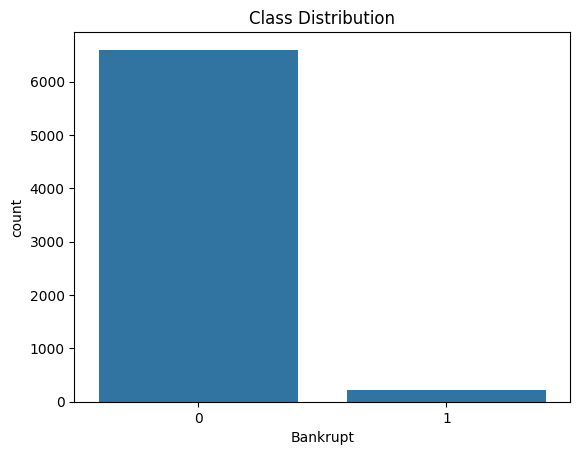

In [15]:
sns.countplot(x='Bankrupt', data=df)
plt.title("Class Distribution")
plt.show()

- There is **severe** Class Imbalance which means Accuracy is a useless metric in this case. As a result, we will have to rely on metrics like Recall, Precision and ROC-AUC.

#### Distribution Comparison

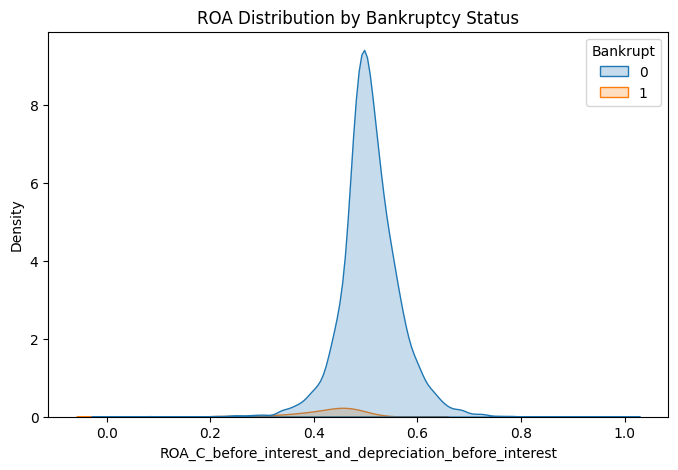

In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='ROA_C_before_interest_and_depreciation_before_interest',
            hue='Bankrupt', fill=True)
plt.title("ROA Distribution by Bankruptcy Status")
plt.show()

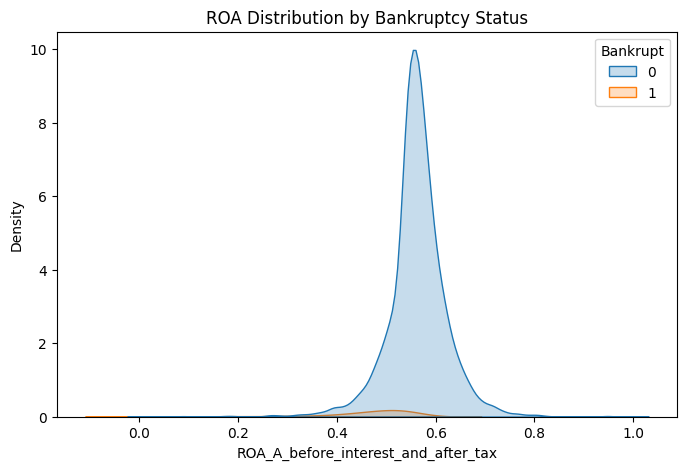

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='ROA_A_before_interest_and_after_tax',
            hue='Bankrupt', fill=True)
plt.title("ROA Distribution by Bankruptcy Status")
plt.show()

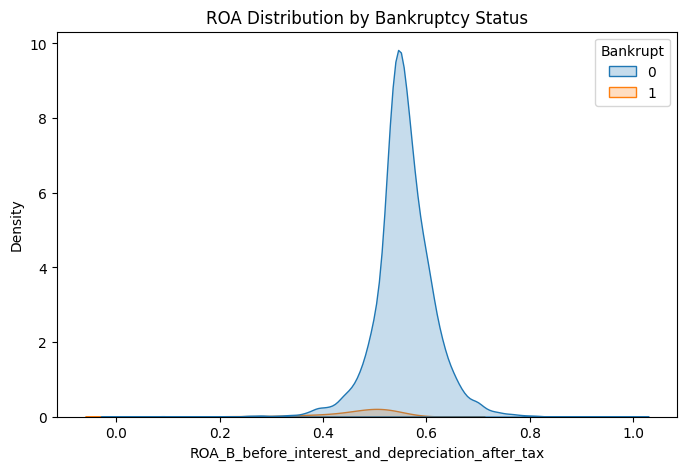

In [18]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='ROA_B_before_interest_and_depreciation_after_tax',
            hue='Bankrupt', fill=True)
plt.title("ROA Distribution by Bankruptcy Status")
plt.show()

- The curves overlap for all **ROA** related faetures which means ROA alone is **not** enough and Bankruptcy is potentially multi-factorial which was expected.

#### Statistical or Hypothesis Testing for all Features

In [19]:
significant_features = []

for col in df.columns:
    if col != 'Bankrupt':
        group1 = df[df['Bankrupt'] == 0][col]
        group2 = df[df['Bankrupt'] == 1][col]
        
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        
        if p_val < 0.05:
            significant_features.append((col, p_val))

len(significant_features)

60

In [20]:
significant_features[:20]

[('ROA_C_before_interest_and_depreciation_before_interest',
  7.042945586411415e-40),
 ('ROA_A_before_interest_and_after_tax', 1.0740205283220016e-33),
 ('ROA_B_before_interest_and_depreciation_after_tax', 1.3267487412314088e-36),
 ('Operating_Gross_Margin', 1.843465949113107e-18),
 ('Realized_Sales_Gross_Margin', 2.7921211969901607e-18),
 ('Pre_tax_net_Interest_Rate', 0.020986388027809395),
 ('After_tax_net_Interest_Rate', 0.038747512946948136),
 ('Non_industry_income_and_expenditure_revenue', 0.005029438766355361),
 ('Continuous_interest_rate_after_tax', 0.02258624337389661),
 ('Research_and_development_expense_rate', 0.0341975978036936),
 ('Cash_flow_rate', 1.5398025501682467e-16),
 ('Interest_bearing_debt_interest_rate', 3.2864246109560365e-08),
 ('Tax_rate_A', 2.6509562209302925e-23),
 ('Net_Value_Per_Share_B', 2.7056291821515466e-61),
 ('Net_Value_Per_Share_A', 8.195422478883063e-61),
 ('Net_Value_Per_Share_C', 7.525617246758084e-60),
 ('Persistent_EPS_in_the_Last_Four_Seasons', 

- Its looks like almost all major profitability variables are statistically different, however, with just 6819 rows, almost everything will be significant. Therefore, we cannot rely on p-value for such a small dataset, so instead we will focus on Effect size.

#### Checking Effect Size

In [21]:
def cohens_d2(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)
    return (x.mean() - y.mean()) / pooled_std

effect_sizes = []

for col in df.columns:
    if col != 'Bankrupt':
        group1 = df[df['Bankrupt'] == 0][col]
        group2 = df[df['Bankrupt'] == 1][col]
        
        d = cohens_d2(group1, group2)
        effect_sizes.append((col, abs(d)))

sorted(effect_sizes, key=lambda x: x[1], reverse=True)[:20]

[('Net_Income_to_Total_Assets', 1.8810832580459242),
 ('ROA_A_before_interest_and_after_tax', 1.6692484875333526),
 ('ROA_B_before_interest_and_depreciation_after_tax', 1.6061127601073222),
 ('ROA_C_before_interest_and_depreciation_before_interest',
  1.5286984037758562),
 ('Debt_ratio', 1.4620395997414166),
 ('Net_worth_Assets', 1.4620395997414164),
 ('Persistent_EPS_in_the_Last_Four_Seasons', 1.2734673091173654),
 ('Retained_Earnings_to_Total_Assets', 1.262621414639274),
 ('Net_profit_before_tax_Paid_in_capital', 1.202432315423807),
 ('Per_Share_Net_profit_before_tax_Yuan', 1.163445321880497),
 ('Current_Liability_to_Assets', 1.1219859824751592),
 ('Working_Capital_to_Total_Assets', 1.1135295400236889),
 ('Net_Income_to_Stockholder_s_Equity', 1.041324251570416),
 ('Borrowing_dependency', 1.0149217596594546),
 ('Current_Liability_to_Current_Assets', 0.9838910158152587),
 ('Liability_to_Equity', 0.9573311536815532),
 ('Net_Value_Per_Share_A', 0.949380232315276),
 ('Net_Value_Per_Share_

- A lot of features have High Effect Size which is a good indicator for possible strong features for modeling. Moreover, profitability features turn out to be strong predictors which aligns with financial theory. This means the dataset is economically sound.

#### Checking Skewness

In [22]:
skewness = df.drop('Bankrupt', axis=1).skew().sort_values(ascending=False)
skewness.head(20)

Fixed_Assets_to_Assets                         82.577237
Current_Ratio                                  82.577237
Total_income_Total_expense                     82.332424
Net_Value_Growth_Rate                          80.291844
Contingent_liabilities_Net_worth               79.670620
Realized_Sales_Gross_Profit_Growth_Rate        77.925109
Continuous_Net_Profit_Growth_Rate              67.097534
Total_Asset_Return_Growth_Rate_Ratio           62.499961
Revenue_per_person                             59.434480
Quick_Assets_Current_Liability                 47.947300
Total_debt_Total_net_worth                     46.355336
Degree_of_Financial_Leverage_DFL               45.724197
Inventory_Working_Capital                      45.332250
Revenue_Per_Share_Yuan                         43.769098
Non_industry_income_and_expenditure_revenue    39.641689
Equity_to_Long_term_Liability                  33.789940
Quick_Ratio                                    31.644913
Average_Collection_Days        

In [23]:
skewness = df.drop('Bankrupt', axis=1).skew().sort_values(ascending=True)
skewness.head(20)

Operating_Profit_Growth_Rate                       -71.688950
Operating_Profit_Rate                              -70.237164
Continuous_interest_rate_after_tax                 -53.200121
After_tax_net_Interest_Rate                        -52.995744
Pre_tax_net_Interest_Rate                          -52.482867
Cash_Flow_to_Sales                                 -47.869112
Net_Income_to_Stockholder_s_Equity                 -37.964701
Working_Capital_Equity                             -36.203654
Working_capitcal_Turnover_Rate                     -28.584611
After_tax_Net_Profit_Growth_Rate                   -25.583367
Regular_Net_Profit_Growth_Rate                     -25.262841
Interest_Expense_Ratio                             -16.822554
Interest_Coverage_Ratio_Interest_expense_to_EBIT   -13.939528
No_credit_Interval                                 -11.585565
Retained_Earnings_to_Total_Assets                  -11.139574
Realized_Sales_Gross_Margin                         -8.066572
Operatin

- The result indicates **Heavy** skewness and **Extreme** outliers. Log transformation might be needed for models like Logistic Regression.

#### Correlation With Target
- Positive correlation increases bankruptcy risk
- Negative correlation decreases bankruptcy risk <I>(protective factor)</I>

In [24]:
corr_target = df.corr()['Bankrupt'].sort_values(ascending=False)
corr_target.head(15)

Bankrupt                                       1.000000
Debt_ratio                                     0.250161
Current_Liability_to_Assets                    0.194494
Borrowing_dependency                           0.176543
Current_Liability_to_Current_Assets            0.171306
Liability_to_Equity                            0.166812
Current_Liability_to_Equity                    0.153828
Current_Liabilities_Equity                     0.153828
Liability_Assets_Flag                          0.139212
Total_expense_Assets                           0.139049
Equity_to_Long_term_Liability                  0.139014
Cash_Current_Liability                         0.077921
Inventory_and_accounts_receivable_Net_value    0.075278
Fixed_Assets_Turnover_Frequency                0.072818
Contingent_liabilities_Net_worth               0.070455
Name: Bankrupt, dtype: float64

- The results make economic sense.

In [25]:
corr_target.tail(15)

Working_Capital_Equity                                   -0.147221
Net_Value_Per_Share_C                                    -0.164784
Net_Value_Per_Share_B                                    -0.165399
Net_Value_Per_Share_A                                    -0.165465
Net_Income_to_Stockholder_s_Equity                       -0.180987
Working_Capital_to_Total_Assets                          -0.193083
Per_Share_Net_profit_before_tax_Yuan                     -0.201395
Net_profit_before_tax_Paid_in_capital                    -0.207857
Retained_Earnings_to_Total_Assets                        -0.217779
Persistent_EPS_in_the_Last_Four_Seasons                  -0.219560
Net_worth_Assets                                         -0.250161
ROA_C_before_interest_and_depreciation_before_interest   -0.260807
ROA_B_before_interest_and_depreciation_after_tax         -0.273051
ROA_A_before_interest_and_after_tax                      -0.282941
Net_Income_to_Total_Assets                               -0.31

- The results indicate perfect financial logic.

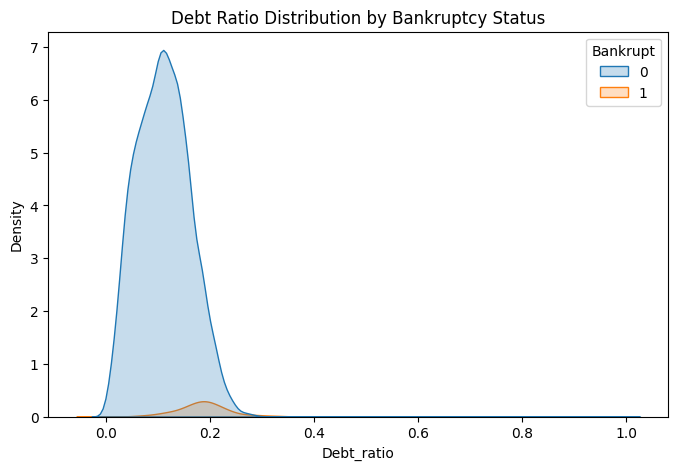

In [26]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Debt_ratio',
            hue='Bankrupt', fill=True)
plt.title("Debt Ratio Distribution by Bankruptcy Status")
plt.show()

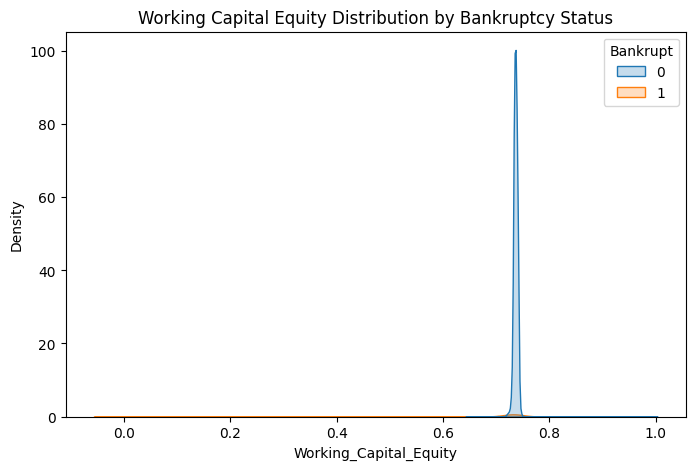

In [27]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Working_Capital_Equity',
            hue='Bankrupt', fill=True)
plt.title("Working Capital Equity Distribution by Bankruptcy Status")
plt.show()

- The above 2 plots indicate that the Strongest Positively and Negatively Correlated features cannot separate Data completely, confirming the hypothesis made earlier that there is no Strong stand alone feature in the dataset and Bankruptcy problem is indeed multi-factorial.

#### Multicollinearity Check

In [28]:
corr_matrix = df.drop('Bankrupt', axis=1).corr()

# Find highly correlated pairs
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i],
                              corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

high_corr[:20]

[('ROA_A_before_interest_and_after_tax',
  'ROA_C_before_interest_and_depreciation_before_interest',
  0.9401237079372291),
 ('ROA_B_before_interest_and_depreciation_after_tax',
  'ROA_C_before_interest_and_depreciation_before_interest',
  0.9868494970091584),
 ('ROA_B_before_interest_and_depreciation_after_tax',
  'ROA_A_before_interest_and_after_tax',
  0.9557406252875469),
 ('Realized_Sales_Gross_Margin', 'Operating_Gross_Margin', 0.999518278122951),
 ('Pre_tax_net_Interest_Rate', 'Operating_Profit_Rate', 0.9164477799917717),
 ('After_tax_net_Interest_Rate',
  'Pre_tax_net_Interest_Rate',
  0.9863790242151972),
 ('Continuous_interest_rate_after_tax',
  'Operating_Profit_Rate',
  0.9155437835954521),
 ('Continuous_interest_rate_after_tax',
  'Pre_tax_net_Interest_Rate',
  0.9936165192552645),
 ('Continuous_interest_rate_after_tax',
  'After_tax_net_Interest_Rate',
  0.9844523286559471),
 ('Net_Value_Per_Share_A', 'Net_Value_Per_Share_B', 0.9993420298908982),
 ('Net_Value_Per_Share_C'

- The results indicate huge redundancy. We might need to drop one from each pair.

#### Checking Variance

In [29]:
variance = df.var().sort_values()
variance.head(20)

Working_capitcal_Turnover_Rate                      0.000080
Cash_Flow_to_Sales                                  0.000087
Total_Asset_Return_Growth_Rate_Ratio                0.000093
Continuous_Net_Profit_Growth_Rate                   0.000101
Inventory_Working_Capital                           0.000110
Operating_Profit_Growth_Rate                        0.000116
Non_industry_income_and_expenditure_revenue         0.000125
Interest_Expense_Ratio                              0.000126
Working_Capital_Equity                              0.000136
Realized_Sales_Gross_Profit_Growth_Rate             0.000146
Total_income_Total_expense                          0.000146
Contingent_liabilities_Net_worth                    0.000149
No_credit_Interval                                  0.000151
Continuous_interest_rate_after_tax                  0.000161
Pre_tax_net_Interest_Rate                           0.000166
Cash_Flow_to_Equity                                 0.000168
Operating_Profit_Rate   

- Some features barely vary, Low variance often means low predictive power. Therefore, we should drop near-zero variance features.

### Observation ->
- This Statistical Analysis revealed a lot of information about the Data in the dataset but most importantly it proved that result from several Tests matched corporate finance theory which in turn indicates that the dataset is of High Quality and can be trusted for making Strategic Business Decisions and for Predictive Modeling.

## Feature Pruning
- Removing Redundant features based on the results from Statistical Analysis.

In [30]:
# Manual Pruning
manual_drop = [
    'ROA_B_before_interest_and_depreciation_after_tax',
    'ROA_C_before_interest_and_depreciation_before_interest',
    'Net_Value_Per_Share_B',
    'Net_Value_Per_Share_C',
    'Net_worth_Assets',
    'Regular_Net_Profit_Growth_Rate',
    'Per_Share_Net_profit_before_tax_Yuan',
    'Operating_Profit_Per_Share_Yuan',
    'Current_Liabilities_Liability'
]

df = df.drop(columns=manual_drop)

print("New shape after manual pruning:", df.shape)

New shape after manual pruning: (6819, 86)


In [31]:
# Algorithmic Pruning based on Effect Size
cohen_dict = dict(effect_sizes)

corr_matrix = df.drop('Bankrupt', axis=1).corr()

features_to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            
            d1 = cohen_dict.get(col1, 0)
            d2 = cohen_dict.get(col2, 0)
            
            # Dropping the one with lower effect size
            if d1 > d2:
                features_to_drop.add(col2)
            else:
                features_to_drop.add(col1)

df = df.drop(columns=list(features_to_drop))

# print("Dropped features:", features_to_drop)
print("New shape:", df.shape)

New shape: (6819, 77)


In [32]:
# Removing Near-Zero Variance Features
variance = df.var()

low_variance_cols = variance[variance < 0.0002].index

df = df.drop(columns=low_variance_cols)

print("New shape after variance pruning:", df.shape)

New shape after variance pruning: (6819, 58)


#### <u>Note -></u>
- We did not perform Outlier Removal since the Dataset is already very small and removing observations will make it even harder to make better predictions.
- Moreover, we don't know if the Outliers in the dataset is the Actual representation of Outliers in the Test Set.
- Without the knowledge of the Real world data, Outlier Removal could be a Risky move as we might be removing genuine Extreme data.

## Splitting the Dataset into Train and Test set
- Splitting is done before the application of any kind of Transformation or Scaling to ensure that the Data is not leaked.

In [33]:
# Defining X and y
X = df.drop('Bankrupt', axis=1)
y = df['Bankrupt']

In [34]:
# Splitting the Dataset
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [35]:
X_train_raw.shape

(5455, 57)

In [36]:
X_test_raw.shape

(1364, 57)

In [37]:
y_train.shape

(5455,)

In [38]:
y_test.shape

(1364,)

#### Making Model Specific Dataset
- Unlike Linear Model, Tree-based model don't require the data to be Transformed or Scaled. Therefore, it is better to keep separate copies of the dataset for different models.

##### Dataset for XGBoost

In [39]:
# Dataset for XGBoost
X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

In [40]:
X_train_xgb.shape

(5455, 57)

In [41]:
X_test_xgb.shape

(1364, 57)

##### Dataset for Logistic Regression

In [42]:
# Identifying numeric non-binary columns
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns

binary_cols = [col for col in numeric_cols if X_train_raw[col].nunique() == 2]

continuous_cols = [col for col in numeric_cols if col not in binary_cols]

In [43]:
# Handling skew using Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')

X_train_log = X_train_raw.copy()
X_test_log = X_test_raw.copy()

X_train_log[continuous_cols] = pt.fit_transform(X_train_raw[continuous_cols])
X_test_log[continuous_cols] = pt.transform(X_test_raw[continuous_cols])

In [44]:
# Re-checking Skew
X_train_log[continuous_cols].skew().sort_values(ascending=False).head(10)

Net_Value_Growth_Rate                    17.253007
Accounts_Receivable_Turnover             10.996670
Average_Collection_Days                   8.890103
Net_Income_to_Stockholder_s_Equity        7.465560
Inventory_Current_Liability               7.379489
Long_term_Liability_to_Current_Assets     6.804015
Cash_Current_Liability                    5.680514
Interest_bearing_debt_interest_rate       5.212595
Total_assets_to_GNP_price                 5.185145
Total_debt_Total_net_worth                3.643716
dtype: float64

In [45]:
# Scaling only X variable and not Scaling y since it is a Classification problem
scaler = StandardScaler()

X_train_log[continuous_cols] = scaler.fit_transform(X_train_log[continuous_cols])
X_test_log[continuous_cols] = scaler.transform(X_test_log[continuous_cols])

In [46]:
X_train_log.shape

(5455, 57)

In [47]:
X_test_log.shape

(1364, 57)

## Building Models

### A. Logistic Regression

##### I. Using Class Weight

In [48]:
log_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_balanced.fit(X_train_log, y_train)

y_pred_bal = log_balanced.predict(X_test_log)
y_prob_bal = log_balanced.predict_proba(X_test_log)[:,1]

In [49]:
print("Logistic Regression with Class Weight: \n")

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall:", recall_score(y_test, y_pred_bal))
print("F1 Score:", f1_score(y_test, y_pred_bal))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_bal))

print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:", classification_report(y_test, y_pred_bal))

Logistic Regression with Class Weight: 

Accuracy: 0.8775659824046921
Precision: 0.17801047120418848
Recall: 0.7727272727272727
F1 Score: 0.2893617021276596

ROC-AUC: 0.8909090909090909

Confusion Matrix: 
 [[1163  157]
 [  10   34]]

Classification Report:               precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.18      0.77      0.29        44

    accuracy                           0.88      1364
   macro avg       0.58      0.83      0.61      1364
weighted avg       0.97      0.88      0.91      1364



In [50]:
thresholds = np.arange(0.05, 0.9, 0.01)

best_thresh = 0
best_score = 0

for t in thresholds:
    y_pred_temp = (y_prob_bal >= t).astype(int)
    score = fbeta_score(y_test, y_pred_temp, beta=2)
    
    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F2 Score:", best_score)

Best Threshold: 0.8500000000000002
Best F2 Score: 0.5212355212355213


In [51]:
threshold = 0.8500000000000002

y_pred_custom_bal = (y_prob_bal >= threshold).astype(int)

print(f"Updated metrics with Threshold = {threshold} using Class Weight\n")
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_custom_bal))
print("\nClassification Report:", classification_report(y_test, y_pred_custom_bal))

Updated metrics with Threshold = 0.8500000000000002 using Class Weight

Confusion Matrix: 
 [[1264   56]
 [  17   27]]

Classification Report:               precision    recall  f1-score   support

           0       0.99      0.96      0.97      1320
           1       0.33      0.61      0.43        44

    accuracy                           0.95      1364
   macro avg       0.66      0.79      0.70      1364
weighted avg       0.97      0.95      0.95      1364



##### II. Using SMOTE

In [52]:
smote = SMOTE(
    sampling_strategy=0.1,  # makes minority 10% of majority
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_log, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_sm.value_counts())

Before SMOTE: Bankrupt
0    5279
1     176
Name: count, dtype: int64

After SMOTE: Bankrupt
0    5279
1     527
Name: count, dtype: int64


In [53]:
log_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = log_smote.predict(X_test_log)
y_prob_sm = log_smote.predict_proba(X_test_log)[:,1]

In [54]:
print("Logistic Regression with SMOTE: \n")

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("Precision:", precision_score(y_test, y_pred_sm))
print("Recall:", recall_score(y_test, y_pred_sm))
print("F1 Score:", f1_score(y_test, y_pred_sm))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_sm))

print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred_sm))
print("\nClassification Report:", classification_report(y_test, y_pred_sm))

Logistic Regression with SMOTE: 

Accuracy: 0.9552785923753666
Precision: 0.3559322033898305
Recall: 0.4772727272727273
F1 Score: 0.4077669902912622

ROC-AUC: 0.8848140495867768

Confusion Matrix: 
 [[1282   38]
 [  23   21]]

Classification Report:               precision    recall  f1-score   support

           0       0.98      0.97      0.98      1320
           1       0.36      0.48      0.41        44

    accuracy                           0.96      1364
   macro avg       0.67      0.72      0.69      1364
weighted avg       0.96      0.96      0.96      1364



In [55]:
thresholds = np.arange(0.05, 0.9, 0.01)

best_thresh = 0
best_score = 0

for t in thresholds:
    y_pred_temp = (y_prob_sm >= t).astype(int)
    score = fbeta_score(y_test, y_pred_temp, beta=2)
    
    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F2 Score:", best_score)

Best Threshold: 0.27
Best F2 Score: 0.509090909090909


In [56]:
threshold = 0.27

y_pred_custom_sm = (y_prob_sm >= threshold).astype(int)

print(f"Updated metrics with Threshold = {threshold} using SMOTE\n")
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_custom_sm))
print("\nClassification Report:", classification_report(y_test, y_pred_custom_sm))

Updated metrics with Threshold = 0.27 using SMOTE

Confusion Matrix: 
 [[1249   71]
 [  16   28]]

Classification Report:               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.28      0.64      0.39        44

    accuracy                           0.94      1364
   macro avg       0.64      0.79      0.68      1364
weighted avg       0.96      0.94      0.95      1364



#### Observation ->
- The results from the 2 different experiments (using Class weight and SMOTE) show that Logistic Regression with Optimal Threshold yield the best Recall-Precision Trade-off in both cases.
- However, considering from the point of view of investors and stakeholders, the primary objective would be to Minimize False Negatives (FN) since labeling a Bankrupt Company as Healthy might turn out to be costly or expensive.
- Therefore, Logistic Regression using Class Weight with the default Threshold of 0.5 is chosen as the best model for Baseline Evaluation.

### B. XGBoost

In [57]:
# Computing scale_pos_weight

# Counting class distribution in training set
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 5279
Positive samples: 176
scale_pos_weight: 29.994318181818183


In [58]:
# Training Baseline XGBoost
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train)

C:\Users\reign\anaconda3\envs\bankruptcy_env\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [59]:
# Probability predictions
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Default threshold 0.5
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print("XGBoost Baseline Results:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Baseline Results:

Accuracy: 0.969208211143695
Precision: 0.5277777777777778
Recall: 0.4318181818181818
F1 Score: 0.47500000000000003

ROC-AUC: 0.9573347107438017

Confusion Matrix:
 [[1303   17]
 [  25   19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1320
           1       0.53      0.43      0.48        44

    accuracy                           0.97      1364
   macro avg       0.75      0.71      0.73      1364
weighted avg       0.97      0.97      0.97      1364



In [60]:
# Tuning Threshold
thresholds = np.arange(0.05, 0.9, 0.01)

best_thresh = 0
best_score = 0

for t in thresholds:
    y_temp = (y_prob_xgb >= t).astype(int)
    score = fbeta_score(y_test, y_temp, beta=2)
    
    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold (F2):", best_thresh)
print("Best F2 Score:", best_score)

Best Threshold (F2): 0.08000000000000002
Best F2 Score: 0.64


In [61]:
# Evaluating again with best Threshold
y_pred_best = (y_prob_xgb >= best_thresh).astype(int)

print("Results with Optimal Threshold:\n")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Results with Optimal Threshold:

[[1278   42]
 [  12   32]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.43      0.73      0.54        44

    accuracy                           0.96      1364
   macro avg       0.71      0.85      0.76      1364
weighted avg       0.97      0.96      0.97      1364



In [62]:
# Computing ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

In [63]:
# Computing AUC Score
auc_score = roc_auc_score(y_test, y_prob_xgb)

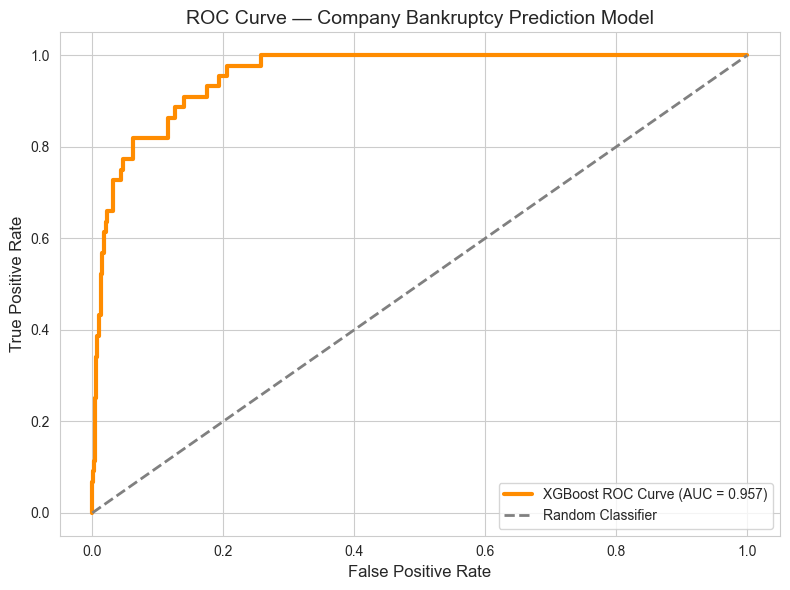

In [64]:
# Plotting the ROC Curve
plt.figure(figsize=(8,6))

sns.set_style("whitegrid")

plt.plot(
    fpr, 
    tpr, 
    color="darkorange",
    lw=3,
    label=f"XGBoost ROC Curve (AUC = {auc_score:.3f})"
)

# Random Baseline
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    lw=2,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Company Bankruptcy Prediction Model", fontsize=14)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

#### Hyperparameter Tuning

In [65]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False
)

# Defining Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

C:\Users\reign\anaconda3\envs\bankruptcy_env\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [66]:
# Fitting the data using GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_xgb, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

C:\Users\reign\anaconda3\envs\bankruptcy_env\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\reign\anaconda3\envs\bankruptcy_env\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV AUC: 0.9347453827156246


In [67]:
# Training the Model with Best Parameters
best_xgb = grid_search.best_estimator_

# Fit again on full training set
best_xgb.fit(X_train_xgb, y_train)

# Predict probabilities
y_prob_best_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

In [68]:
# Finding Optimal Threshold
thresholds = np.arange(0.01, 0.5, 0.01)

best_thresh = 0
best_f2 = 0

for t in thresholds:
    y_temp = (y_prob_best_xgb >= t).astype(int)
    score = fbeta_score(y_test, y_temp, beta=2)
    
    if score > best_f2:
        best_f2 = score
        best_thresh = t

print("Optimal Threshold:", best_thresh)
print("Best F2 Score:", best_f2)

Optimal Threshold: 0.46
Best F2 Score: 0.509915014164306


In [69]:
y_pred_final = (y_prob_best_xgb >= best_thresh).astype(int)

print("Tuned XGBoost Result:\n")

print("ROC-AUC:", roc_auc_score(y_test, y_prob_best_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Tuned XGBoost Result:

ROC-AUC: 0.9518422865013775

Confusion Matrix:
 [[1179  141]
 [   8   36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.20      0.82      0.33        44

    accuracy                           0.89      1364
   macro avg       0.60      0.86      0.63      1364
weighted avg       0.97      0.89      0.92      1364



#### Observation ->
- Baseline XGBoost Model with Threshold 0.08 has the best ROC-AUC score and Recall-Precision Trade-off than the Tuned XGBoost and best Logistic Regression Model.
- As a result, Baseline XGBoost Model is identified as the best model for this task and we will use that Model to determine Key Drivers for Prediction using Feature Importance and SHAP.
- Business Recommendations will be made using this Model while keeping the Goals of the Problem statement in mind.

## Identifying Key Financial Risk Drivers

<Figure size 1000x800 with 0 Axes>

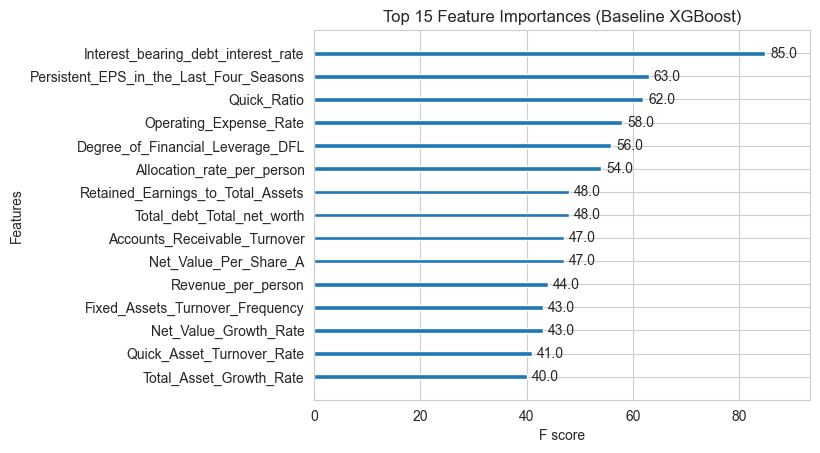

In [70]:
# Plotting Features Importance for the Baseline XGBoost Model
plt.figure(figsize=(10,8))
plot_importance(xgb_model, max_num_features=15)
plt.title("Top 15 Feature Importances (Baseline XGBoost)")
plt.show()

In [71]:
# Plotting Features Importance from Permutation Importance
perm_importance = permutation_importance(
    xgb_model,
    X_test_xgb,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature': X_test_xgb.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_df.head(15))

                                    Feature  Importance
6   Persistent_EPS_in_the_Last_Four_Seasons    0.032250
13                              Quick_Ratio    0.023085
14               Total_debt_Total_net_worth    0.012831
25                       Revenue_per_person    0.009010
20             Accounts_Receivable_Turnover    0.008655
3       Interest_bearing_debt_interest_rate    0.007195
27               Allocation_rate_per_person    0.007149
2                            Cash_flow_rate    0.005499
38        Retained_Earnings_to_Total_Assets    0.005430
47                   Cash_Flow_to_Liability    0.004141
17                     Borrowing_dependency    0.003974
53                    Gross_Profit_to_Sales    0.003836
1     Research_and_development_expense_rate    0.003628
8                    Revenue_Per_Share_Yuan    0.003259
5                     Net_Value_Per_Share_A    0.002383


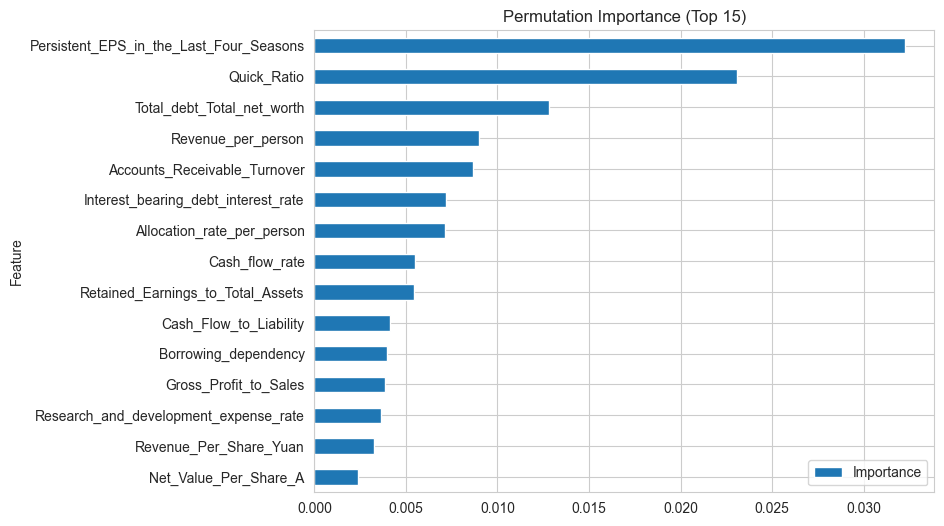

In [72]:
perm_df.head(15).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Top 15)")
plt.show()

In [73]:
# SHAP Setup

# Creating explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculating SHAP values
shap_values = explainer.shap_values(X_test_xgb)

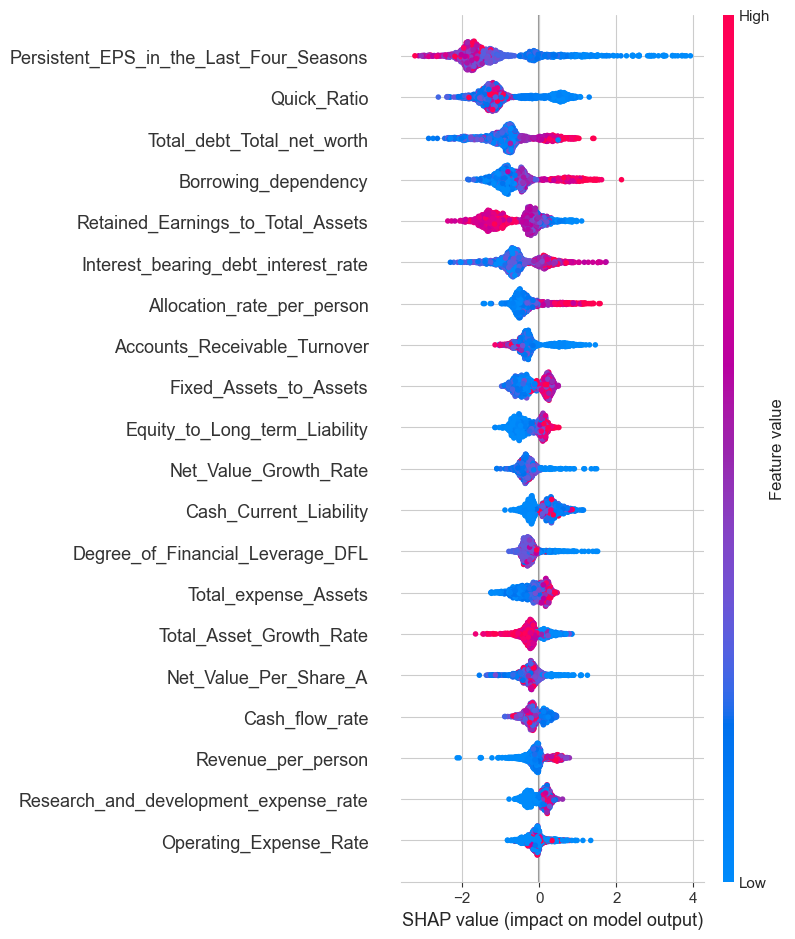

In [74]:
# Plotting SHAP Summary Plot
shap.summary_plot(shap_values, X_test_xgb)

- The plot shows that the model is learning the correct relationship in every observed aspect.

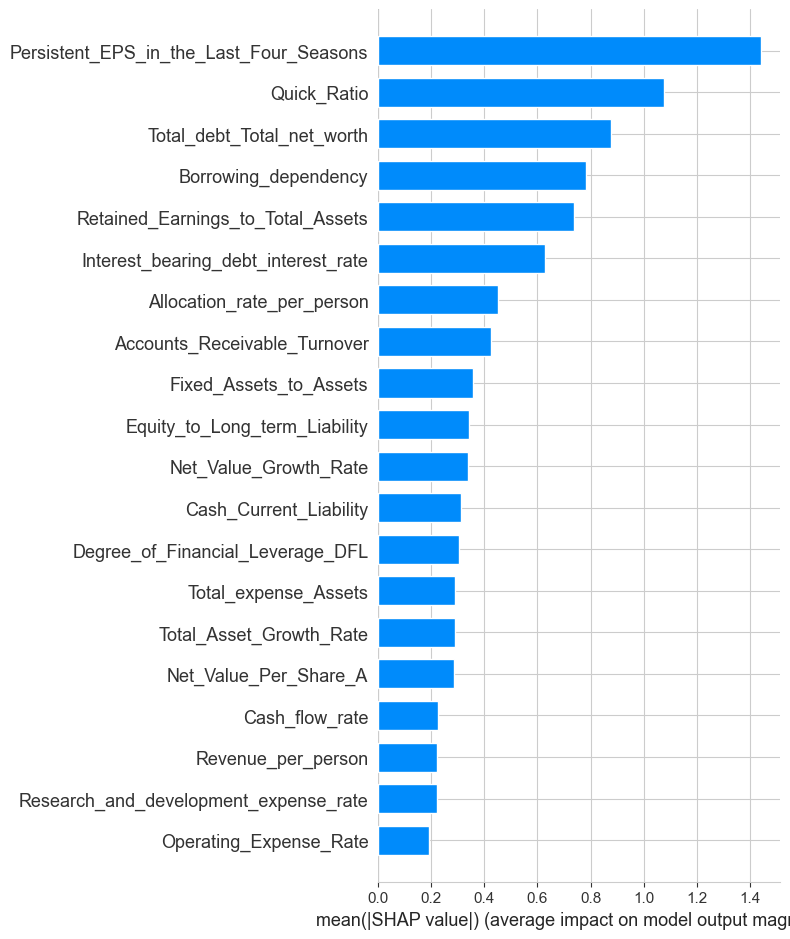

In [75]:
# Plotting SHAP Bar Plot
shap.summary_plot(shap_values, X_test_xgb, plot_type="bar")

#### Explaining one True Positive Case (Bankrupt Company)

In [76]:
# Finding index of correctly predicted bankrupt firm
for i in range(len(y_test)):
    if y_test.iloc[i] == 1 and (y_prob_best_xgb[i] >= 0.08):
        index_to_explain = i
        break

print("Explaining test index:", index_to_explain)

Explaining test index: 54


In [77]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[index_to_explain],
    X_test_xgb.iloc[index_to_explain]
)

### Observation ->
- The top 4 repeating features across all 3 importance methods are :-
    - Persistent_EPS_in_the_Last_Four_Seasons
    - Quick_Ratio
    - Total_debt_Total_net_worth
    - Interest_bearing_debt_interest_rate
- The repeating appearance shows that the signal is real and not random noise.
- The dominating features align with financial theory.
- The SHAP tells us why probability for Bankruptcy is high and which features drive that.
- The top 4 features show the structural weaknesses which are Poor Earnings Persistence, Weak Liquidity, High Leverage and High Interest Burden and that will become the basis for our Strategic Recommendation.
- The Summary Plot from SHAP shows that the XGBoost model is not learning inverted relationship.
- The TP case (Bankrupt Company) shows negative forces dominate resulting into being classified as Bankrupt which is economically consistent.
- All these signs indicate that the XGBoost model is not overfitting and is behaving like a real Risk Model which is explainable. Therefore, the model can be trusted.

## Making Strategic Recommendations

- The model outputs Probabilities which not only can used to predict bankruptcy but also segment companies into High-Risk, Medium-Risk and Low-Risk Firms.
- The SHAP exposes the risk drivers which in turn exposes the structural weakness pattern.
- The recommendations here are made according to the structural weaknesses exposed by the top 4 repeating features across all 3 importance methods.
- Specific recommendations are only made for High and Medium Risk firms to mitigate risk.
- A recommendation related to Portfolio Level Integration is made to address Low Risk firms and to identify early warning signs of financial distress.

- **High Risk Firms** (Probability > 0.5)
    - Reduce capital exposure or allocation to high-risk firms
    - Increase monitoring frequency (maybe monthly)
- **Medium Risk Firms** (Probability = 0.2 - 0.5)
    - Monitor liquidity & leverage quarterly
    - Conduct stress testing on cash flow sustainability
- **Portfolio Level Integration**
    - Embed probability score into investment screening process and capital allocation

# THE END